In [1]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
import os

zarr_path = r"/Users/sasakinozomu/code/MTCargoSim/analysis/data/cargo_msd_seeds.zarr"
data = zarr.open_array(zarr_path, mode='r')
print(f"Data shape: {data.shape}")
plt.style.use('../../my_style.mplstyle')

Data shape: (201, 10000)


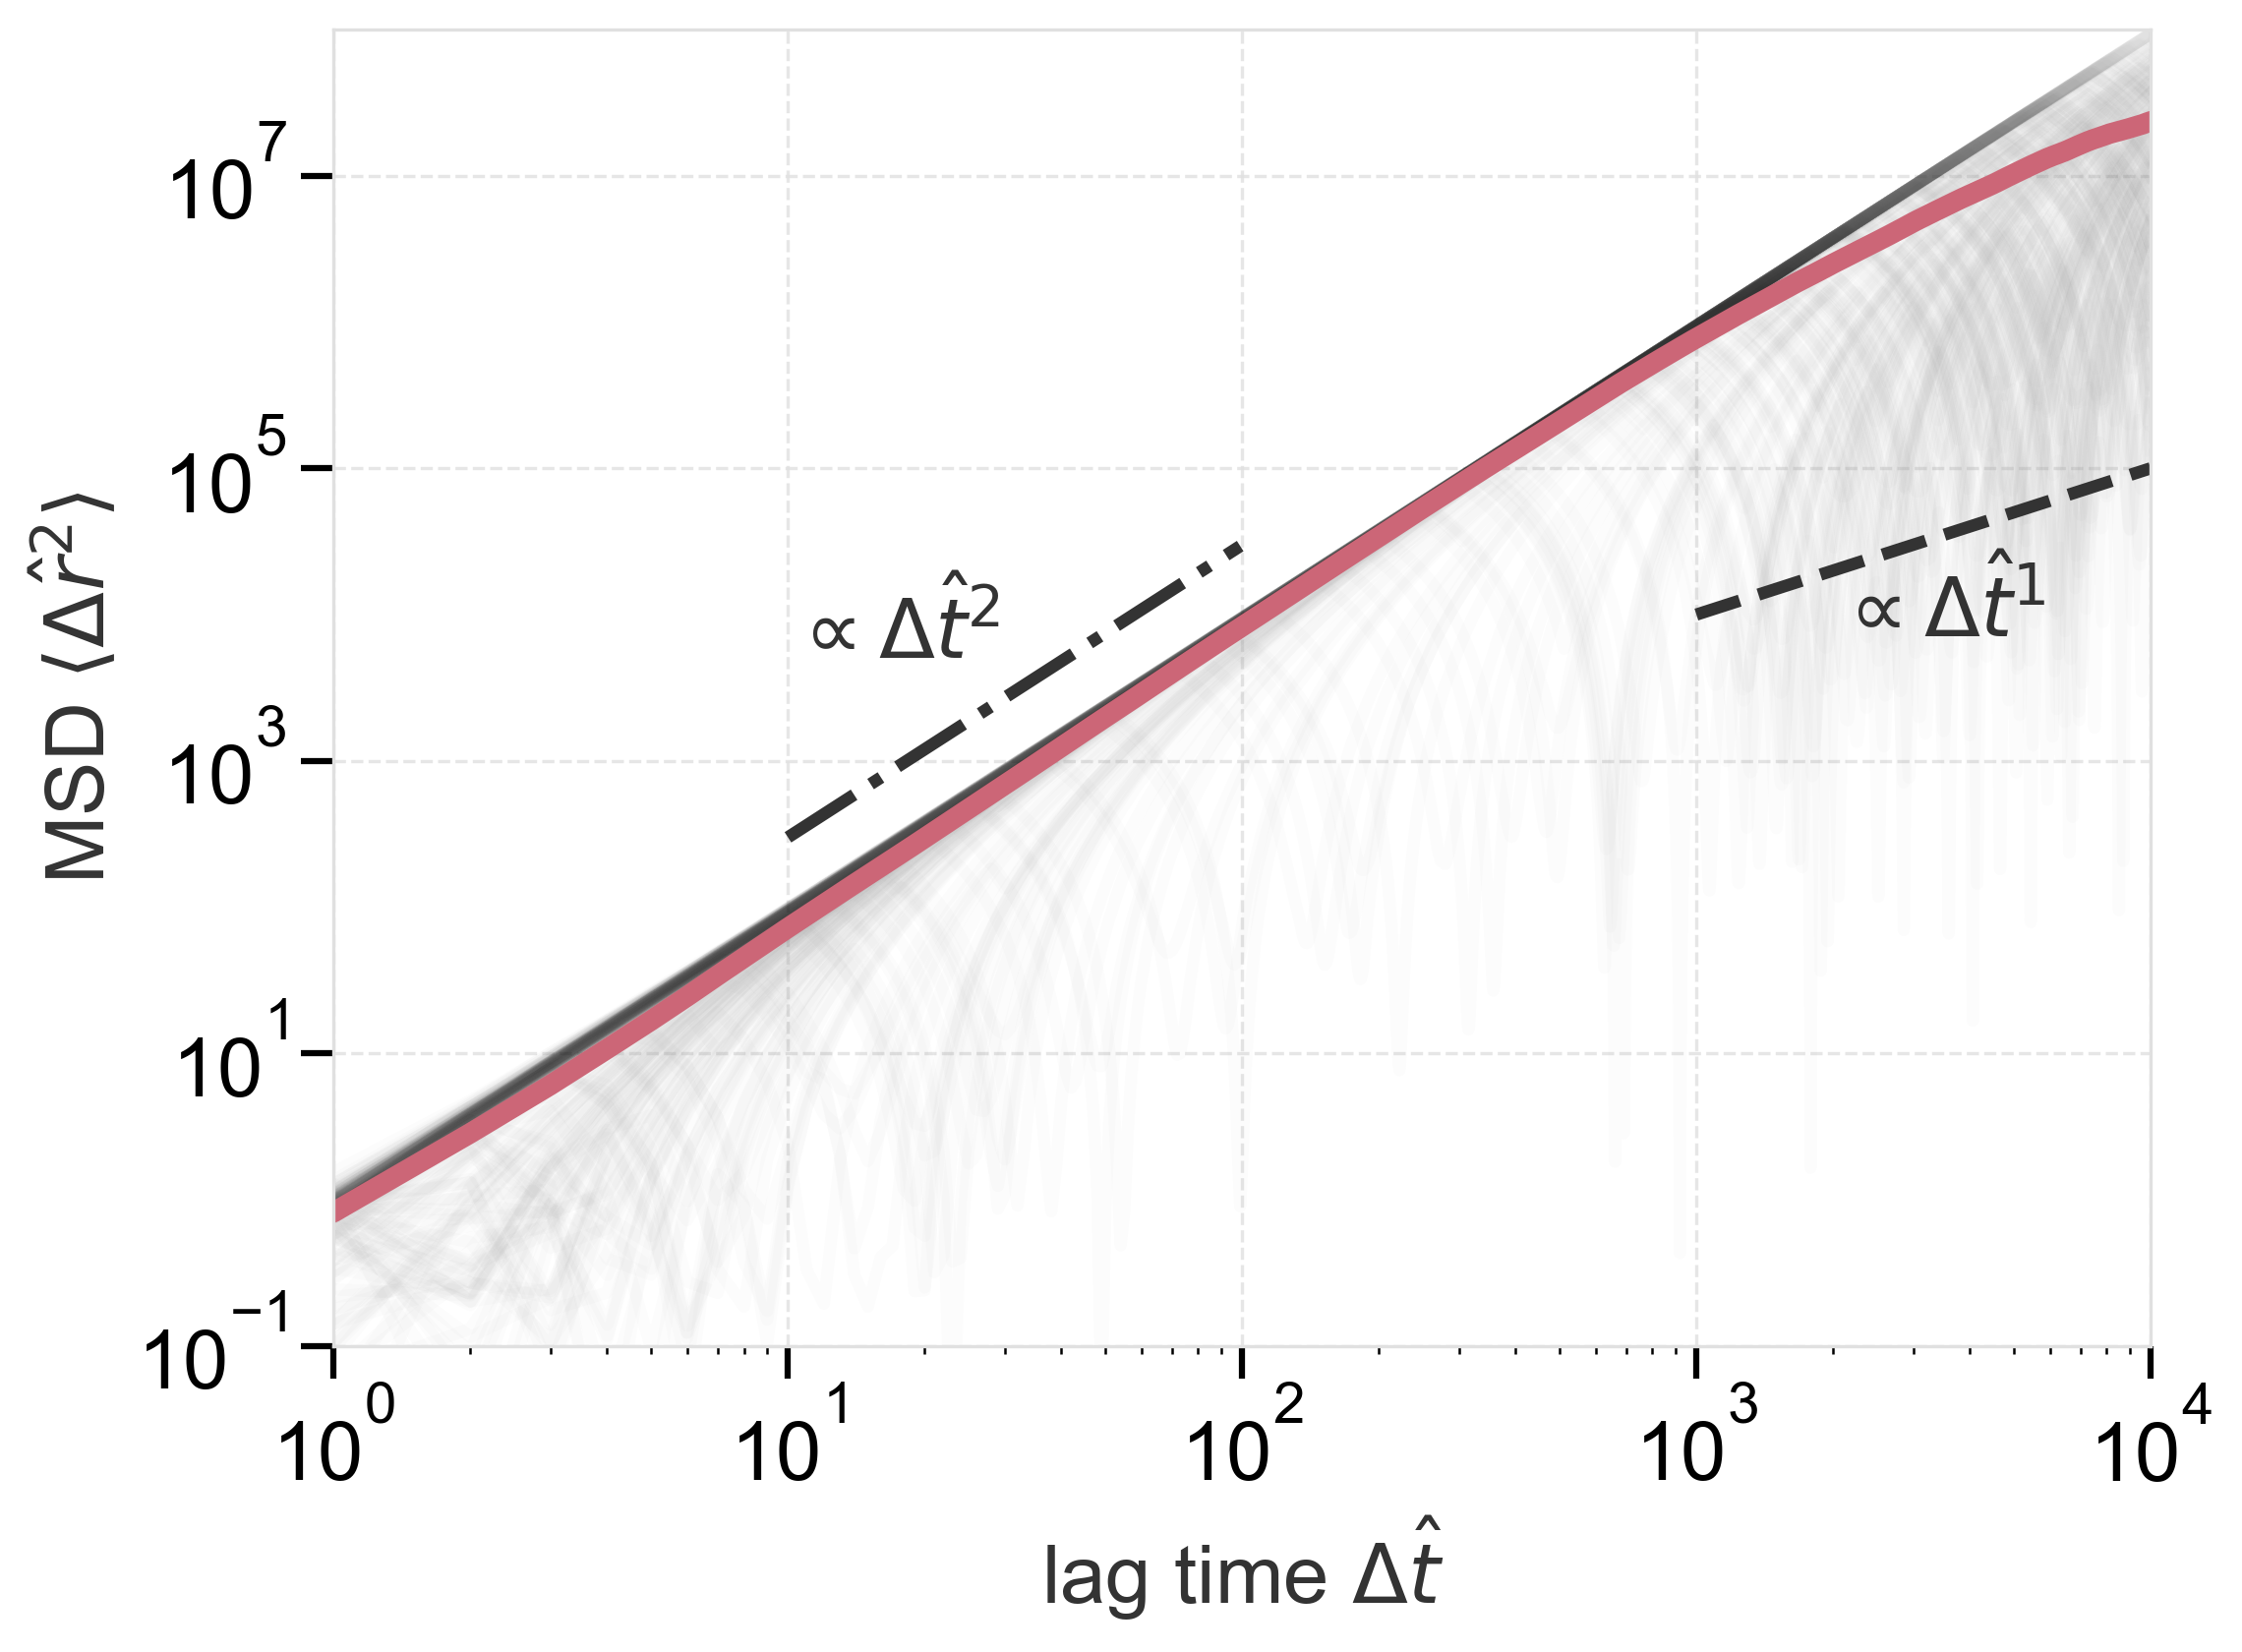

In [8]:
len = data.shape[1]
t = np.arange(len)
fig, ax = plt.subplots()

for i in range(data.shape[0]):
    ax.plot(t, data[i, :], alpha=0.01, color="#333333")

ax.plot(t, np.mean(data, axis=0), label='Ensemble', lw=5)

t1 = np.arange(1e3, 1e4)
t2 = np.arange(1e1, 1e2)

y1 = 1.0e1 * t1 ** 1.0
y2 = 3.0e-0 * t2 ** 2.0

ax.plot(t1, y1, c = '#333333', linestyle = '--')
ax.plot(t2, y2, c = '#333333', linestyle = '-.')

ax.text(2e3, 7e3, r'$\propto \Delta \hat{t}^{1}$', color='#333333')
ax.text(1e1, 5e3, r'$\propto \Delta \hat{t}^{2}$', color='#333333')


ax.set(
    xlim=(1e0, 1e4),
    ylim=(1e-1, 1e8),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta \hat{t}$',
    ylabel='MSD $\\langle \\Delta \\hat{r}^2 \\rangle$'
    )

cd=os.getcwd()

fig.savefig(f"{cd}/figure/MSD.png", bbox_inches='tight')
fig.savefig(f"{cd}/figure/MSD.pdf", bbox_inches='tight')